In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

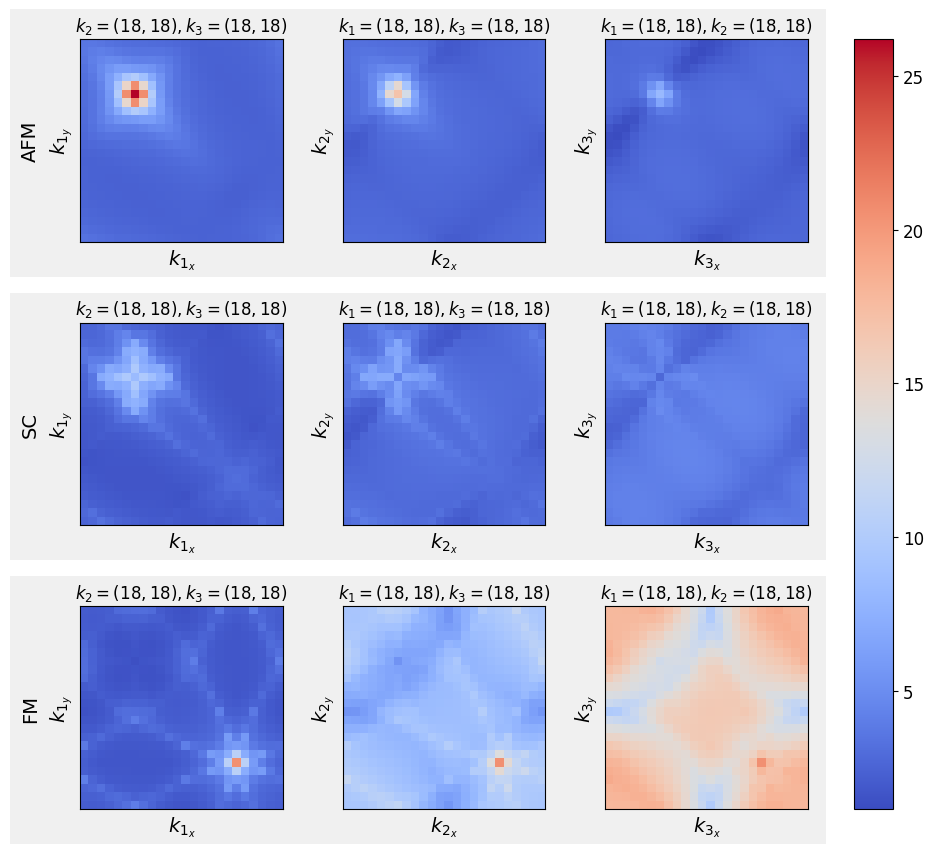

In [116]:
files_names = ['tp0.090000_mu0.360000', 'tp0.270000_mu1.080000', 'tp0.410000_mu1.640000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices, i=18, axis=3, vmin=None, vmax=None)

## vertex statistics

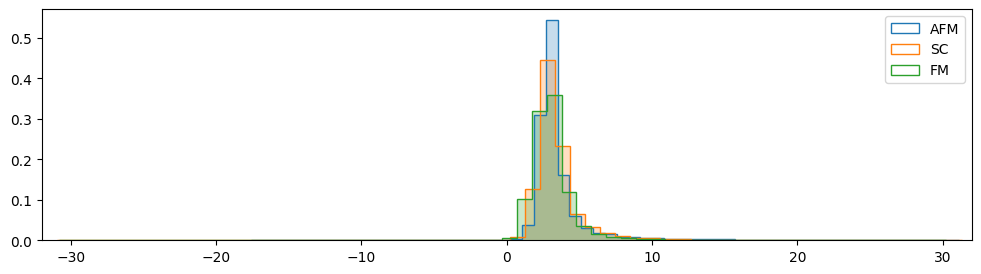

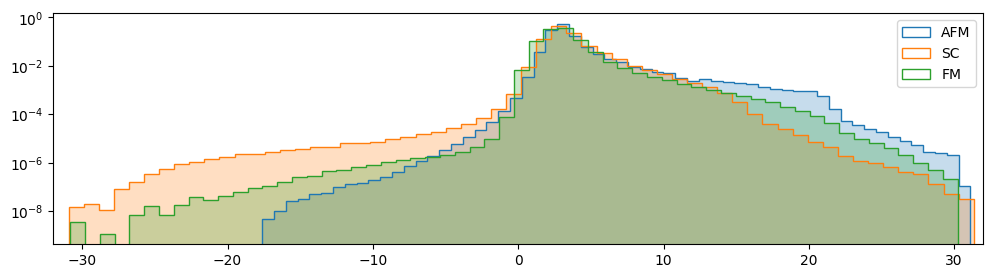

,min,max,mean,sum
AFM,-17.621026,31.116854,3.516467,13440147922.163141
SC,-30.943928,31.344199,3.435302,13129930305.072977
FM,-30.830774,30.236403,3.128338,11956693254.854389


In [3]:
df, data = verteval.vertex_statistics(data_dir)
verteval.plot_statistics(data)
verteval.plot_statistics(data, log=True)
df

## correlation

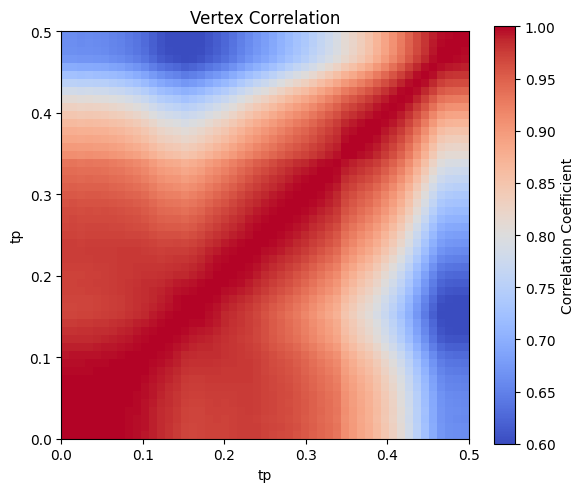

In [9]:
cor_mat = np.load(f'cor_mat_real.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation", vmin=0.6)

In [10]:
cor_mat.min()

np.float64(0.5897979984026432)

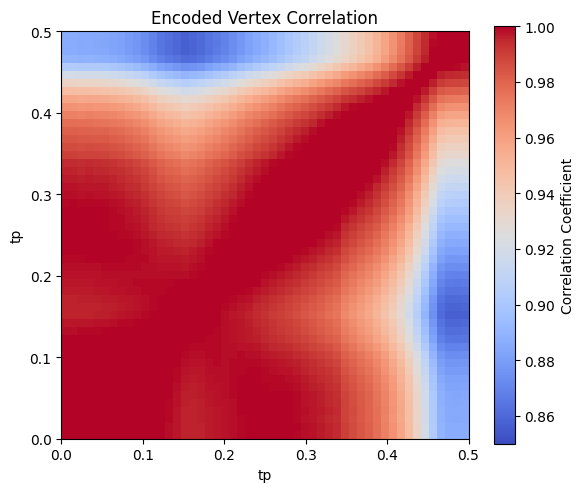

In [6]:
cor_mat = np.load(f'cor_mat_latent_1-1-ld32.npy')
vertvis.plot_correlation(cor_mat, "Encoded Vertex Correlation", vmin=0.85)

In [4]:
cor_mat.min()

np.float64(0.8568989038467407)

## compare autoencoder models

In [26]:
rmse_df.drop(columns=['tp', 'train_data']).groupby(['run_id', 'ld', 's']).mean()

rmse
run_id ld s              
1_1    32 24000  0.007771
1_2    32 24000  0.066215
2_1_1  8  24000  0.169867
       16 24000  0.097626
       20 24000  0.074753
       24 24000  0.046875
       32 2000   0.068156
          8000   0.040277
          12000  0.047274
          16000  0.018830
          24000  0.023504
2_1_2  32 24000  0.043141
2_2_1  32 24000  0.011346
2_2_2  32 24000  0.050307
2_3_1  32 24000  0.024447
2_3_2  32 24000  0.067075
3_1    32 24000  0.016433
3_2    32 24000  0.054052
3_3    32 24000  0.019987

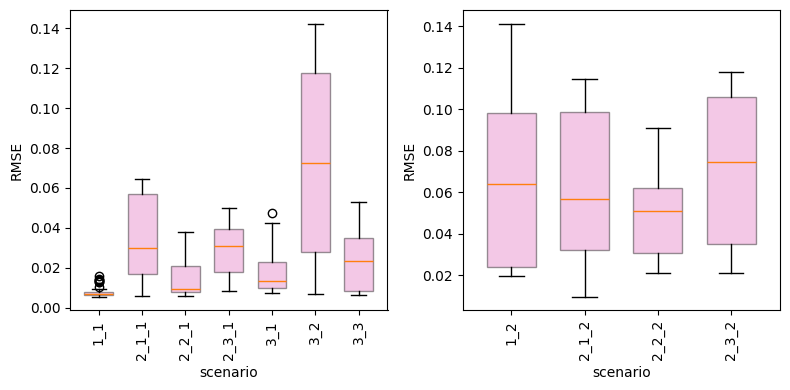

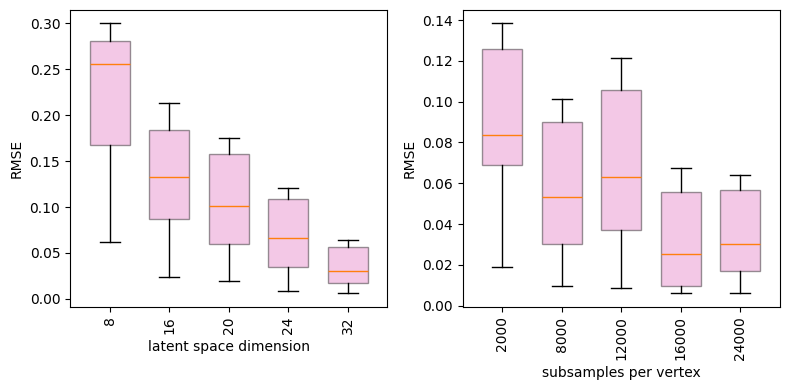

In [25]:
verteval.plot_rmse_boxplots(rmse_df, figsize=(8, 4), train_data=False)

In [65]:
df = df.reset_index()
df['run_id'] = df['run_id'].str.replace('_', '-')
df

,run_id,ld,s,rmse
0,3-1,32,24000,0.022396
1,3-2,32,24000,0.047253
2,3-3,32,24000,0.056652


In [66]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & ld & s & rmse \\
\midrule
3-1 & 32 & 24000 & 0.022 \\
3-2 & 32 & 24000 & 0.047 \\
3-3 & 32 & 24000 & 0.057 \\
\bottomrule
\end{tabular}



mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519
training data only - mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519
reconstruction RMSE for 1_1_ld32_s24000


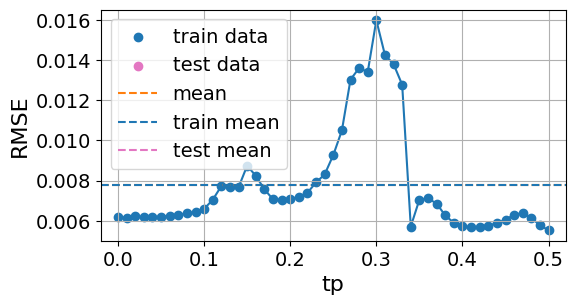

mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165
training data only - mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165
reconstruction RMSE for 1_2_ld32_s24000


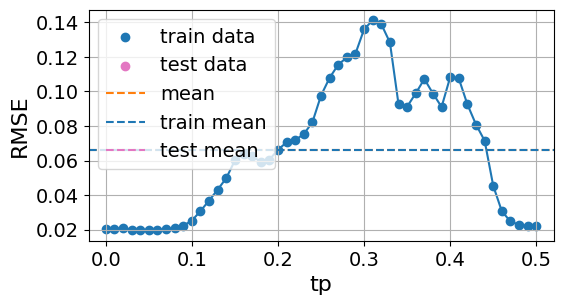

mean: 0.1698668099740209, min: 0.0563486057711932, max: 0.3000015634505707
training data only - mean: 0.14087214403289694, min: 0.0563486057711932, max: 0.2658101576997915
test data only - mean: 0.2112877613184837, min: 0.0621132165191485, max: 0.3000015634505707
reconstruction RMSE for 2_1_1_ld8_s24000


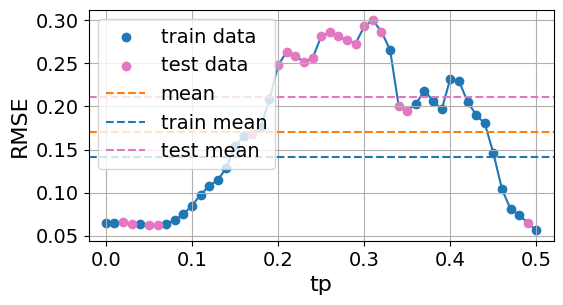

mean: 0.09762621477913366, min: 0.0241947069982136, max: 0.2133893678188678
training data only - mean: 0.07732067287264986, min: 0.0246249054269442, max: 0.1906810669757207
test data only - mean: 0.12663413178839622, min: 0.0241947069982136, max: 0.2133893678188678
reconstruction RMSE for 2_1_1_ld16_s24000


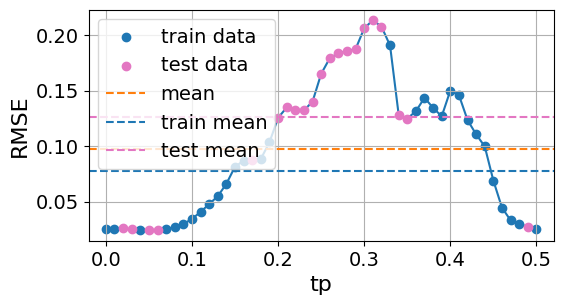

mean: 0.07475323522414207, min: 0.0184777530350107, max: 0.1753884285875548
training data only - mean: 0.0555143574817175, min: 0.0184777530350107, max: 0.158693618902675
test data only - mean: 0.10223734628474859, min: 0.0192393017482349, max: 0.1753884285875548
reconstruction RMSE for 2_1_1_ld20_s24000


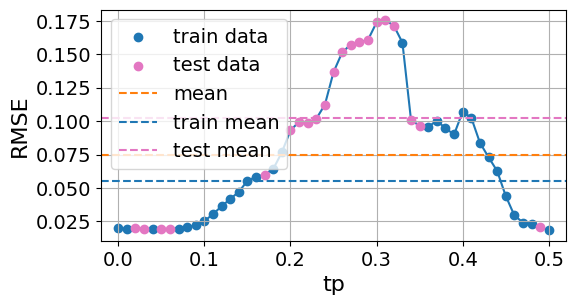

mean: 0.04687466911381581, min: 0.0066598890367751, max: 0.1212319111065108
training data only - mean: 0.03232695460149508, min: 0.0066598890367751, max: 0.109820575611055
test data only - mean: 0.06765711841713115, min: 0.0079885547434377, max: 0.1212319111065108
reconstruction RMSE for 2_1_1_ld24_s24000


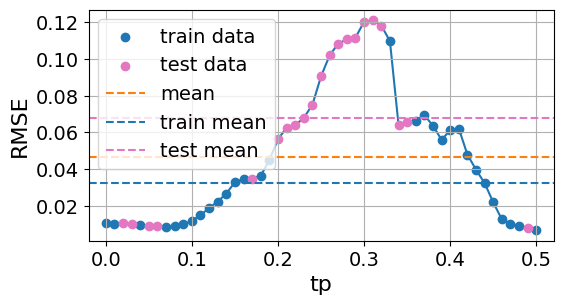

mean: 0.06815647241268447, min: 0.0175134435269492, max: 0.1383782627135698
training data only - mean: 0.05598650067169839, min: 0.0175134435269492, max: 0.1222293287601558
test data only - mean: 0.08554214632837888, min: 0.0190059665365078, max: 0.1383782627135698
reconstruction RMSE for 2_1_1_ld32_s2000


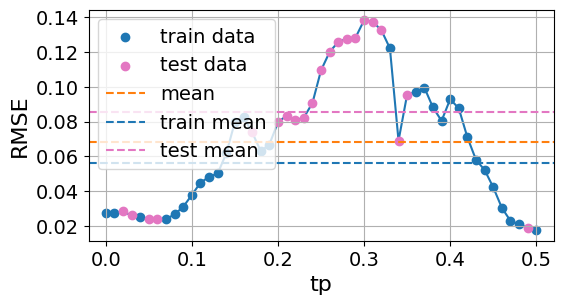

mean: 0.040277421137467385, min: 0.0090315193747978, max: 0.1014380282616174
training data only - mean: 0.028698438605253913, min: 0.0090315193747978, max: 0.0905986799937623
test data only - mean: 0.056818824754915245, min: 0.0096920363975437, max: 0.1014380282616174
reconstruction RMSE for 2_1_1_ld32_s8000


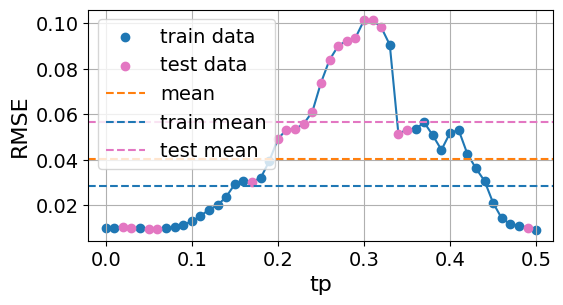

mean: 0.04727399561707828, min: 0.0083833833764575, max: 0.1212743311547443
training data only - mean: 0.033985063781142875, min: 0.0083833833764575, max: 0.1082389475284535
test data only - mean: 0.06625818395412887, min: 0.0087415325092283, max: 0.1212743311547443
reconstruction RMSE for 2_1_1_ld32_s12000


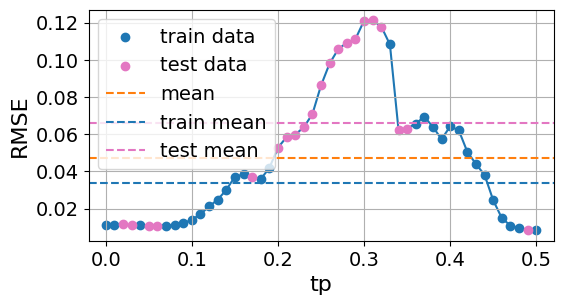

mean: 0.018829849971130682, min: 0.0058888844835213, max: 0.0674691477831666
training data only - mean: 0.009966583433182982, min: 0.0058888844835213, max: 0.0481953859932453
test data only - mean: 0.031491659311055964, min: 0.006229225736502, max: 0.0674691477831666
reconstruction RMSE for 2_1_1_ld32_s16000


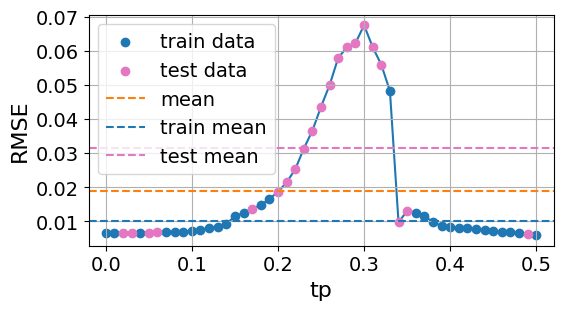

mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296
reconstruction RMSE for 2_1_1_ld32_s24000


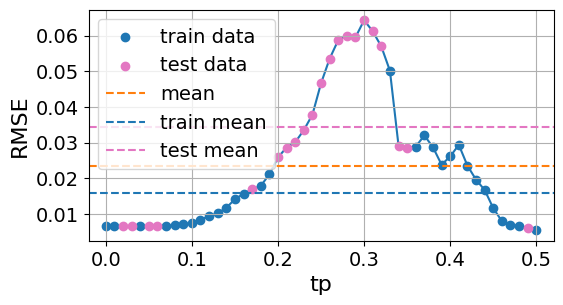

mean: 0.04314076637809767, min: 0.0097367703815004, max: 0.1144680651146157
training data only - mean: 0.03055552548797525, min: 0.0097367703815004, max: 0.1015223760608776
test data only - mean: 0.06111968193541538, min: 0.0097547245927211, max: 0.1144680651146157
reconstruction RMSE for 2_1_2_ld32_s24000


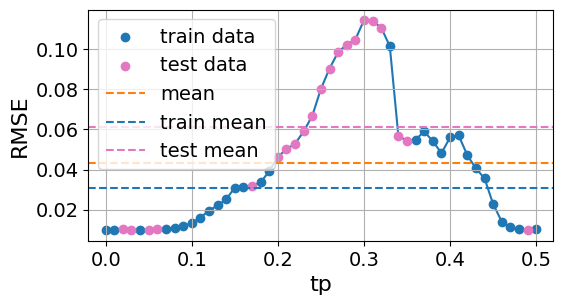

mean: 0.011346324672715713, min: 0.0058296047811714, max: 0.0376805900382426
training data only - mean: 0.007874428499352064, min: 0.0058585200357042, max: 0.0126556805233798
test data only - mean: 0.014684686377873067, min: 0.0058296047811714, max: 0.0376805900382426
reconstruction RMSE for 2_2_1_ld32_s24000


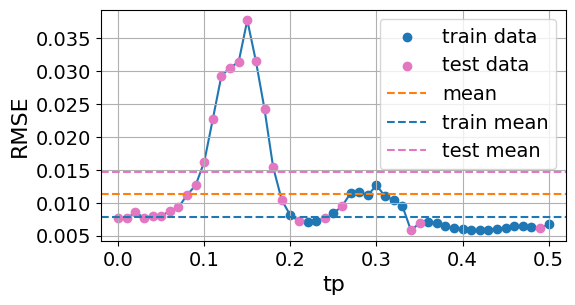

mean: 0.050307302391825584, min: 0.0211225351602496, max: 0.0908340031611275
training data only - mean: 0.051611620401530764, min: 0.0218633941180148, max: 0.0688014826663395
test data only - mean: 0.04905315045941675, min: 0.0211225351602496, max: 0.0908340031611275
reconstruction RMSE for 2_2_2_ld32_s24000


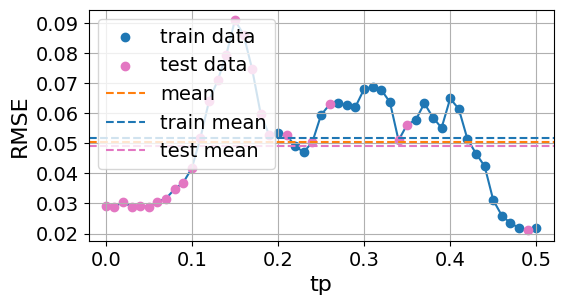

mean: 0.024446766145674214, min: 0.008417594942537, max: 0.0501274356605866
training data only - mean: 0.019537599560778503, min: 0.0084585091309584, max: 0.0412011397862826
test data only - mean: 0.029552299393965753, min: 0.008417594942537, max: 0.0501274356605866
reconstruction RMSE for 2_3_1_ld32_s24000


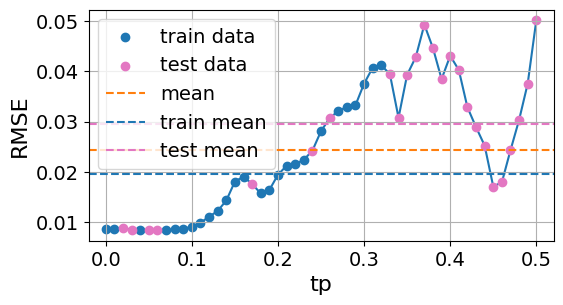

mean: 0.0670749375226252, min: 0.0209938889883941, max: 0.1295632148579371
training data only - mean: 0.06456942527975959, min: 0.0212229920017746, max: 0.1295632148579371
test data only - mean: 0.0696806702552054, min: 0.0209938889883941, max: 0.1178974209923496
reconstruction RMSE for 2_3_2_ld32_s24000


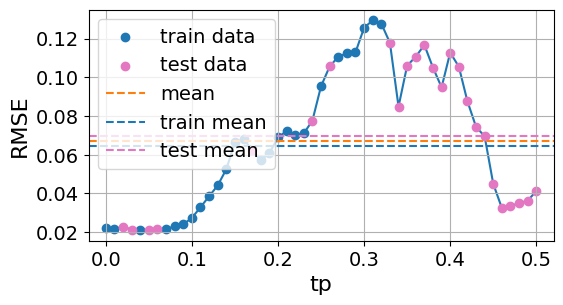

mean: 0.016432640288140465, min: 0.0073222943543964, max: 0.0475276224161039
training data only - mean: 0.01015621203985333, min: 0.0085851273079696, max: 0.0117938620285331
test data only - mean: 0.01796347644625928, min: 0.0073222943543964, max: 0.0475276224161039
reconstruction RMSE for 3_1_ld32_s24000


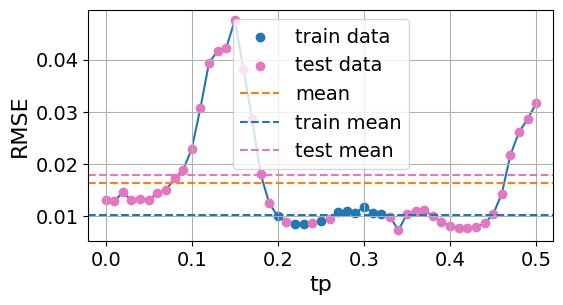

mean: 0.05405205146477475, min: 0.0068304631837742, max: 0.1423498029275165
training data only - mean: 0.01428682297744393, min: 0.0069133213537977, max: 0.035640568504099
test data only - mean: 0.07223044163041169, min: 0.0068304631837742, max: 0.1423498029275165
reconstruction RMSE for 3_2_ld32_s24000


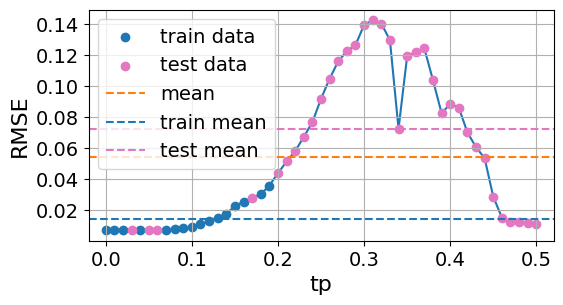

mean: 0.01998738447340126, min: 0.0061421676426792, max: 0.0528070905557745
training data only - mean: 0.008324228514100543, min: 0.0061421676426792, max: 0.0299489592649665
test data only - mean: 0.024400470512055586, min: 0.0063116254150922, max: 0.0528070905557745
reconstruction RMSE for 3_3_ld32_s24000


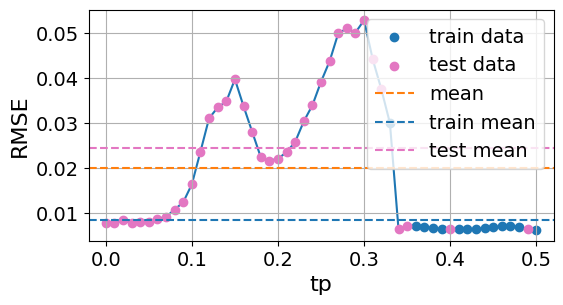

In [28]:
for (run_id, ld, s), group in rmse_df.groupby(['run_id', 'ld', 's']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}', figsize=(6,3), font_size=16)

## convergence

In [2]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir()])
labels = {
    '1_1': '1-1 all vertices, simple AE',
    '1_2': '1-2 all vertices, contrastive AE',
    '2_1_1': '2-1-1 exclude SC, simple AE',
    # '2_1_1_nextTp': '2-1-1 predicting next vertex',
    '2_1_2': '2-1-2 exclude SC, contrastive AE',
    '2_2_1': '2-2-1 exclude AFM, simple AE',
    '2_2_2': '2-2-2 exclude AFM, contrastive AE',
    '2_3_1': '2-3-1 exclude FM, simple AE',
    '2_3_2': '2-3-2 exclude FM, contrastive AE',
    '3_1': '3-1 SC only, simple AE',
    '3_2': '3-2 AFM only, simple AE',
    '3_3': '3-3 FM only, simple AE',
}

filtered_folders = folders  # set this to plot only some runs
filtered_labels = []
for f in filtered_folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    filtered_labels.append(f"{pref}, {suff}")
tensorboard_data = vis.get_tensorboard_data(base_path, filtered_folders, filtered_labels)
tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)

tensorboard_data['ld'] = tensorboard_data['run'].str.extract(r'.*ld(\d+)').astype(pd.Int16Dtype()).fillna(32)
tensorboard_data['s'] = tensorboard_data['run'].str.extract(r'.*s(\d+)').astype(pd.Int16Dtype()).fillna(24000)
tensorboard_data['run'] = tensorboard_data['run'].str.split(',').str[0]

tensorboard_stats

,wall_time,epoch,min_loss,min_loss_epoch,max_epochs_no_decrease
run,,,,,
"1_1, ld32",40.99,24999,0.000061,22990,2679
"1_2, ld32",29.99,49999,0.017237,24593,219
"2_1_1, ld16",24.17,24999,0.008373,24910,157
"2_1_1, ld20",24.29,24999,0.004415,24840,196
"2_1_1, ld24",24.36,24999,0.001679,24578,978
"2_1_1, ld32",24.40,24999,0.000371,24726,729
"2_1_1, ld8",24.41,24999,0.023746,24872,107
"2_1_1, s12000",12.06,24999,0.001851,24792,295
"2_1_1, s16000",15.93,24999,0.000074,20270,1857


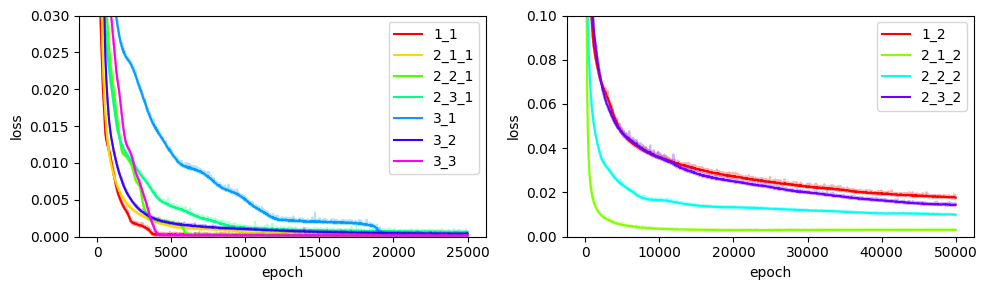

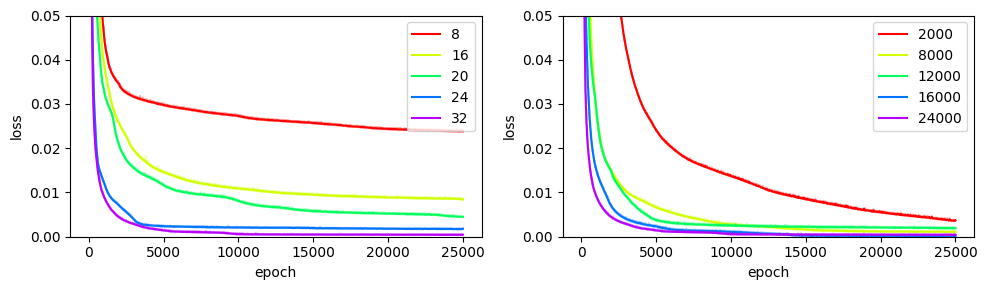

In [8]:
verteval.plot_loss_progress(tensorboard_data.dropna(), y_maxs=(0.03, 0.1, 0.05, 0.05), figsize=(10, 3), log=False)

## compare phase classifier models

In [31]:
classification_df.set_index(['run_id', 'ld', 's'])

,,,f1,conf_mat
run_id,ld,s,,
2_1_1,32,8000,0.958721,"[[1.0, 0.0, 0.0], [0.03445, 0.8989625, 0.06658..."
2_1_2,32,24000,0.969004,"[[1.0, 0.0, 0.0], [0.0272375, 0.92625, 0.04651..."
3_2,32,24000,0.961452,"[[1.0, 0.0, 0.0], [0.032825, 0.9044375, 0.0627..."
2_2_2,32,24000,0.967883,"[[1.0, 0.0, 0.0], [0.0252875, 0.92423125, 0.05..."
2_1_1,8,24000,0.952377,"[[1.0, 0.0, 0.0], [0.0422375, 0.8940875, 0.063..."
2_3_2,32,24000,0.970094,"[[1.0, 0.0, 0.0], [0.01784375, 0.93701875, 0.0..."
3_1,32,24000,0.956281,"[[1.0, 0.0, 0.0], [0.0387, 0.89531875, 0.06598..."
1_1,32,24000,0.956973,"[[1.0, 0.0, 0.0], [0.04370625, 0.8924, 0.06389..."
2_1_1,20,24000,0.963304,"[[1.0, 0.0, 0.0], [0.0316125, 0.91429375, 0.05..."


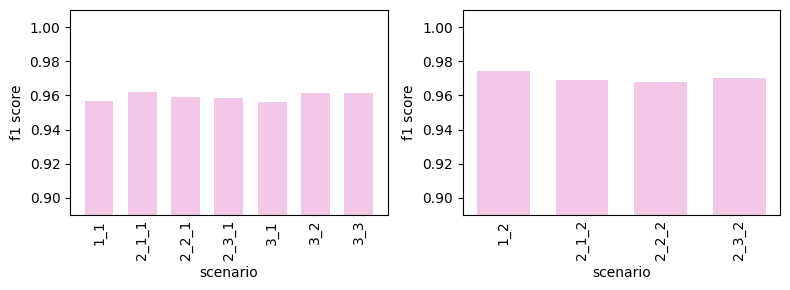

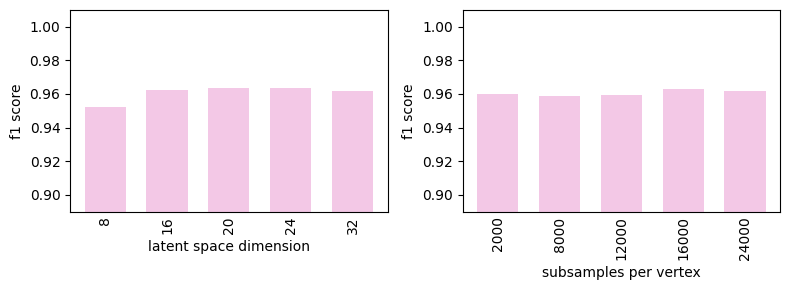

In [34]:
verteval.plot_classification_results(classification_df, figsize=(8, 3))

In [95]:
df = df.reset_index()
df['run_id'] = df['run_id'].str.replace('_', '-')
df

,run_id,ld,s,f1
0,2-1-2,8,24000,0.951040
1,2-1-2,16,24000,0.959179
2,2-1-2,20,24000,0.966148
3,2-1-2,24,24000,0.965585
4,2-1-2,32,24000,0.966148


In [96]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & ld & s & f1 \\
\midrule
2-1-2 & 8 & 24000 & 0.951 \\
2-1-2 & 16 & 24000 & 0.959 \\
2-1-2 & 20 & 24000 & 0.966 \\
2-1-2 & 24 & 24000 & 0.966 \\
2-1-2 & 32 & 24000 & 0.966 \\
\bottomrule
\end{tabular}



2_1_1_ld32_s8000


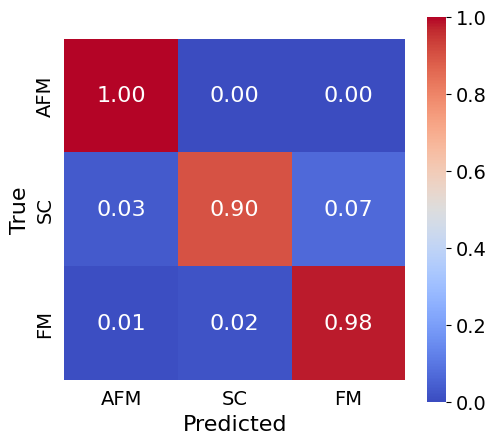

2_1_2_ld32_s24000


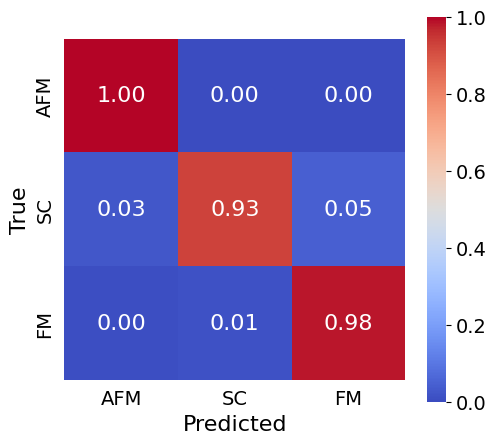

3_2_ld32_s24000


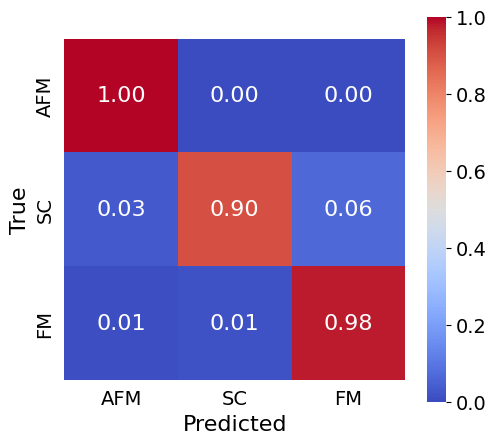

2_2_2_ld32_s24000


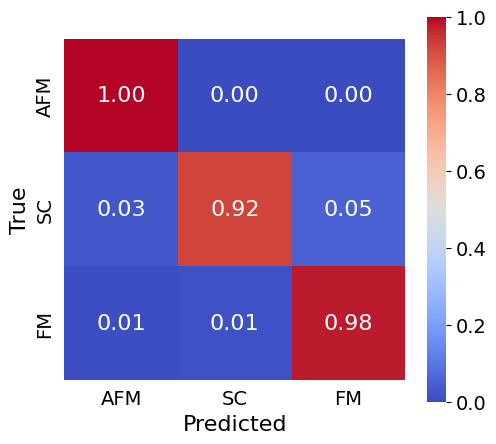

2_1_1_ld8_s24000


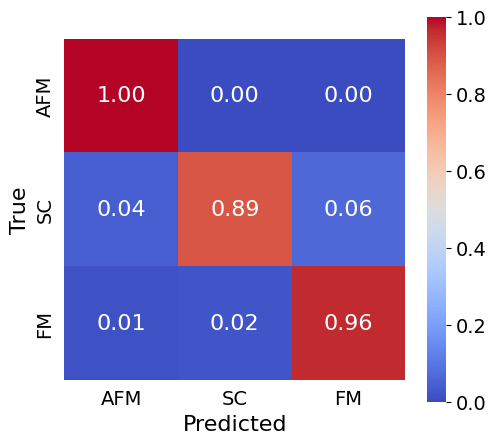

2_3_2_ld32_s24000


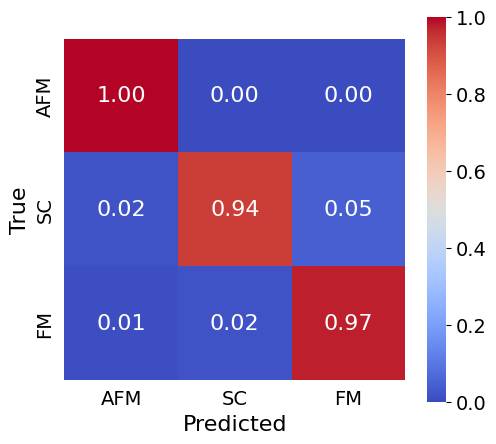

3_1_ld32_s24000


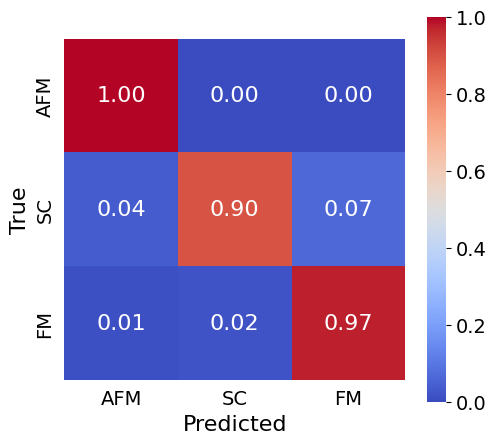

1_1_ld32_s24000


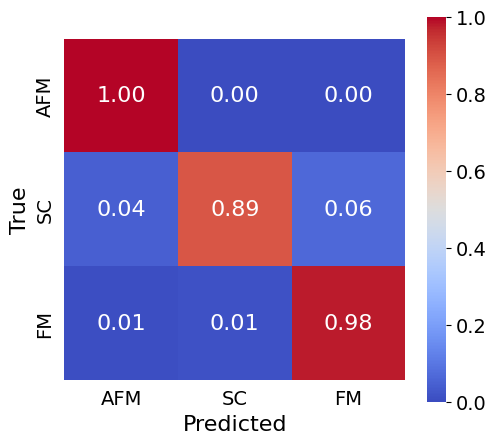

2_1_1_ld20_s24000


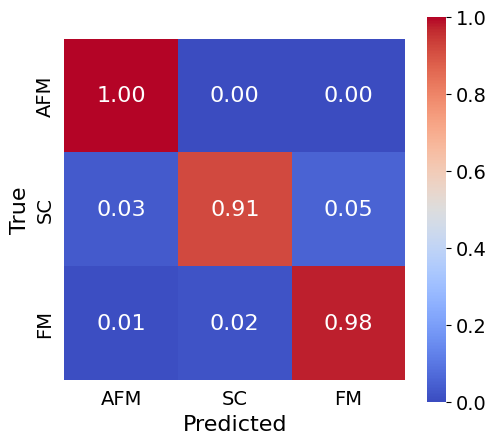

2_2_1_ld32_s24000


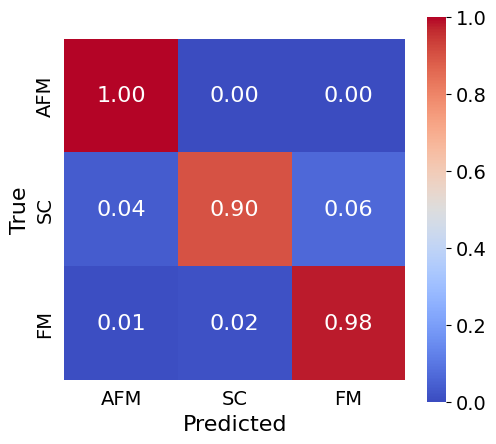

3_3_ld32_s24000


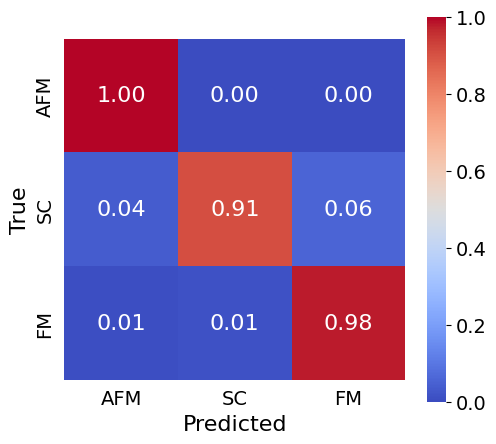

2_1_1_ld32_s24000


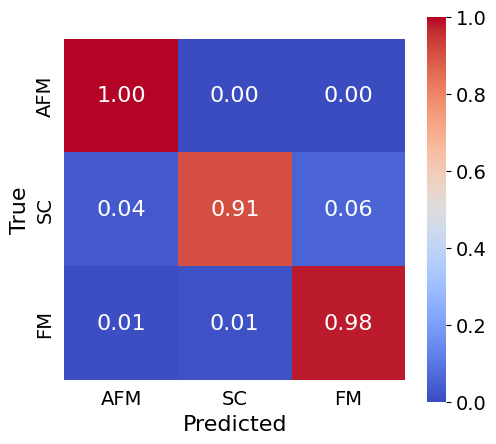

2_1_1_ld32_s12000


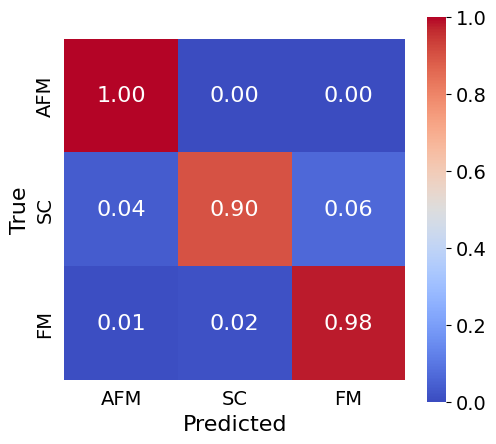

2_1_1_ld32_s16000


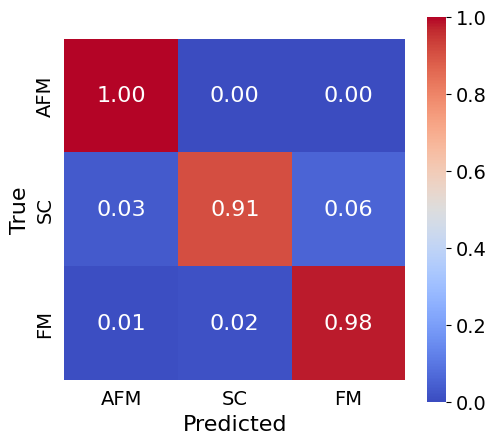

2_1_1_ld24_s24000


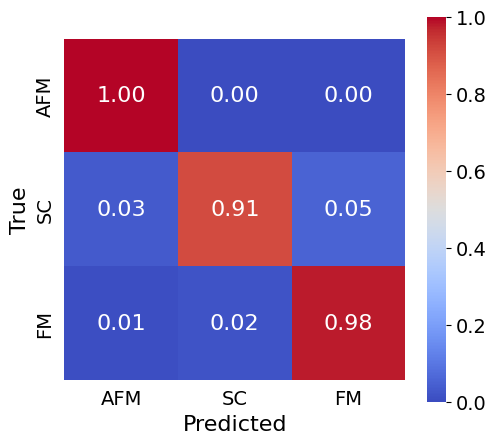

1_2_ld32_s24000


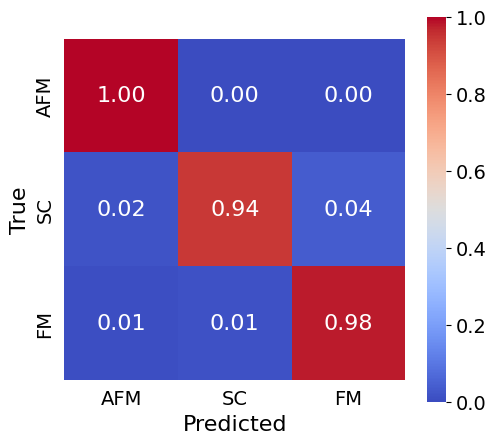

2_1_1_ld32_s2000


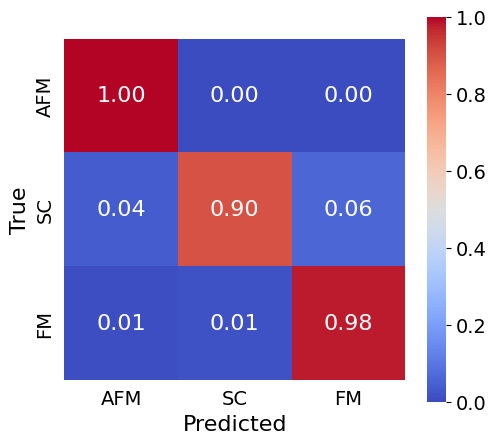

2_1_1_ld16_s24000


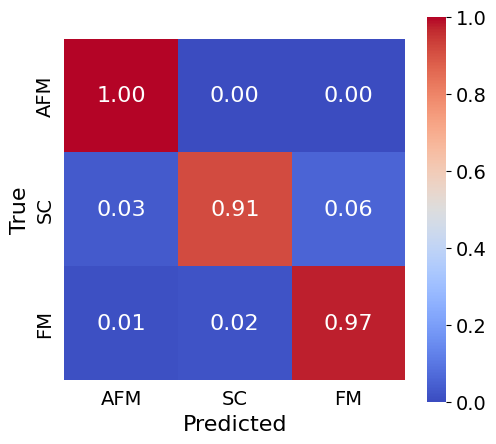

2_3_1_ld32_s24000


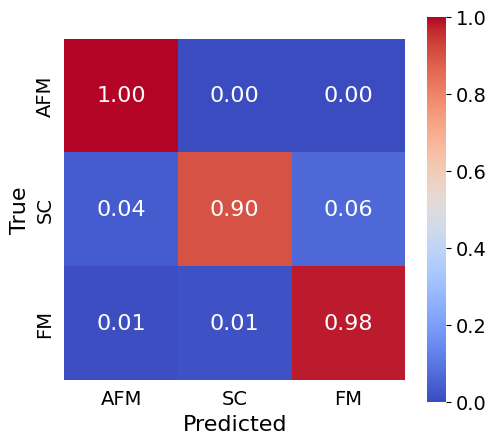

In [35]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]
for i, row in classification_df.iterrows():
    vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}", labels)

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [8]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_ld8', '2_1_1_ld32']
tp_to_plot = [0.22, 0.33]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

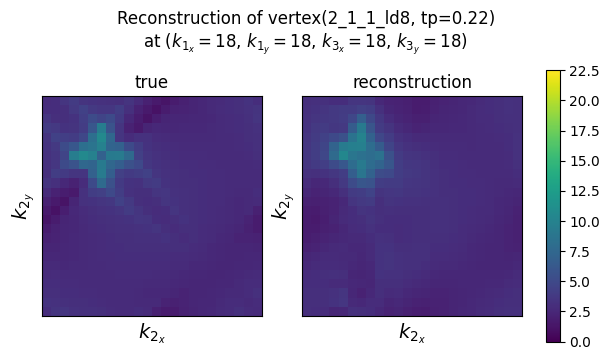

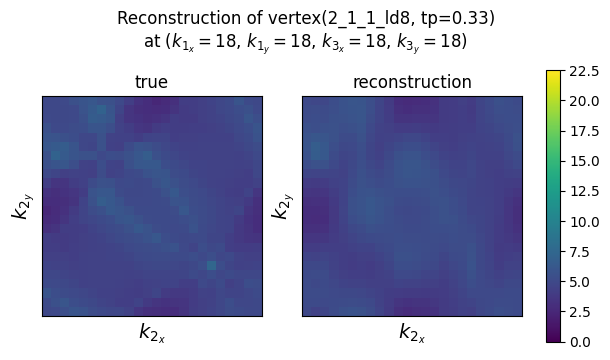

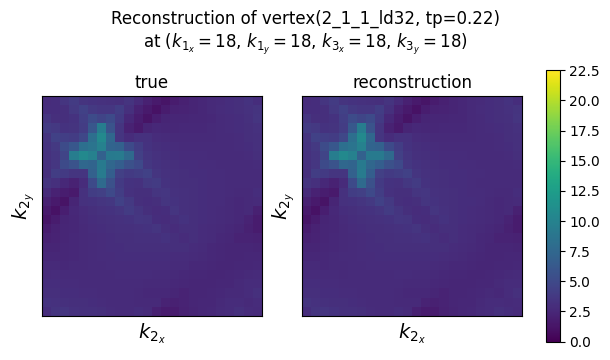

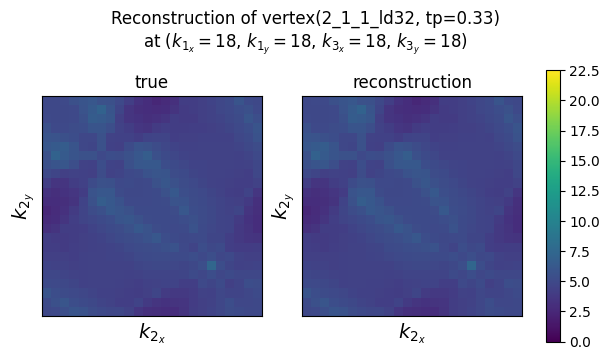

In [9]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'reconstruction': pred_slice}
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), 
                                  title=f'Reconstruction of vertex({run_id}, tp={tp})\nat ({params_str})', vmin=0.0, vmax=22.5)